# Logistic Regression

## Step 0: Get Iris data

In [1]:
import os
import numpy as np
import pandas as pd

try:
    s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
    print('From URL:', s)
    df = pd.read_csv(s,
                     header=None,
                     encoding='utf-8')

except HTTPError:
    s = 'iris.data'
    print('From local Iris path:', s)
    df = pd.read_csv(s,
                     header=None,
                     encoding='utf-8')

n_unique_categories = df[4].nunique()
unique_categories = df[4].unique()
print(f"There are {n_unique_categories} categories: {unique_categories}")

df.tail()

From URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
There are 3 categories: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Fitting a dataset with X: (100, 2) and y: (100,)


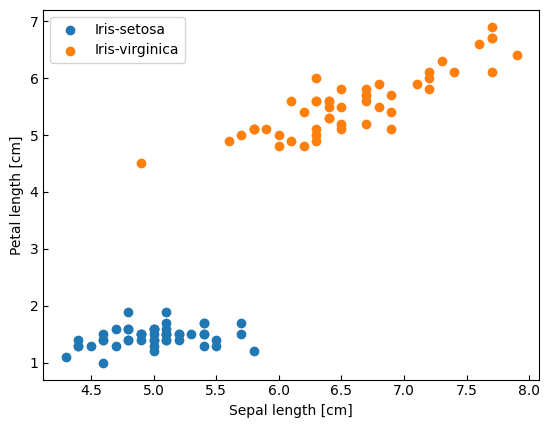

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# We are going to classify Iris-setosa from Iris virginica
labels = ['Iris-setosa', 'Iris-virginica']
mask = df[4].isin(labels)
df = df.loc[mask]

X = df[[0, 2]].values
y = df[4].values
y_mapped = np.zeros(y.shape, dtype=int)
y_mapped[y == labels[1]] = 1

print(f"Fitting a dataset with X: {X.shape} and y: {y.shape}")

ax = plt.figure().gca()
for label in labels:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=label)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')
ax.legend()

## Step 1: Define logistic regression model

In [3]:
import numpy as np

class LogisticRegression:
    """ Full-batch gradient descent variant
        
        Parameters:
        -----------
        eta : float - Learning rate between 0 and 1
        n_iter : int - Iterations over the trainind ata
        random_seed : int - Random seed

        Attributes:
        -----------
        w_ : 1d array of weights
        b_ : bias term
        losses_ : MSE loss each epoch
    """
    def __init__(self, eta=0.01, n_iter=20, standardize=True, random_seed=42):
        self.eta = eta
        self.n_iter = n_iter
        self.standardize = standardize
        self.random_seed = random_seed

    def fit(self, X, y):
        """ X : ndarray with shape [n_examples, n_features]
            y : ndarray with shape [n_examples,]
        """
        self.rng = np.random.default_rng(seed=self.random_seed)
        self.w_ = self.rng.normal(loc=0, scale=0.01, size=X.shape[1])
        self.b_ = np.float_(0.)

        self.losses_ = []

        # Collect mean/std for inputs since we know standardization helps
        if self.standardize:
            self.X_mean_ = X.mean(axis=0)
            self.X_std_ = X.std(axis=0)
        else:
            self.X_mean_ = 0.
            self.X_std_ = 1.

        X_std = self._standardize(X)

        # iterate over epochs
        for _ in range(self.n_iter):
             loss = self._fit_epoch(X_std, y)
             self.losses_.append(loss)

        return self

    def _fit_epoch(self, X, y):
        z = self.pre_activation(X)
        pred = self.activation(z)
        diff = y - pred
        self.w_ += 2. * self.eta * diff.dot(X) / X.shape[0]
        self.b_ += 2. * self.eta * diff.mean()

        loss = -y.dot(np.log(pred)) - (1-y).dot(np.log(1-pred))
        return loss.mean()

    def _standardize(self, X):
        return (X - self.X_mean_) / self.X_std_

    def pre_activation(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):
        z = self.pre_activation(self._standardize(X))
        return np.where(self.activation(z) >= 0.5, 1, 0)

## Step 2: Train logistic regression model

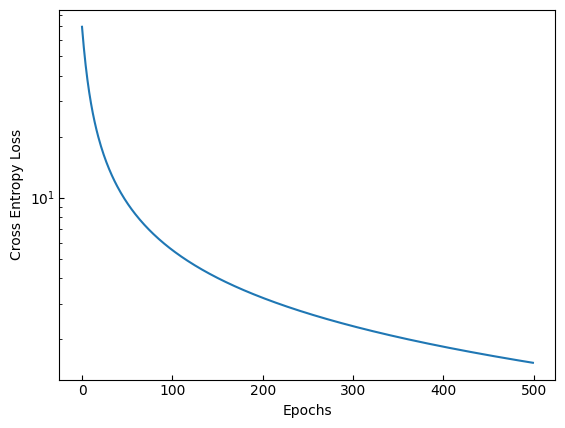

In [12]:
lr_model = LogisticRegression(eta=0.1, n_iter=500, standardize=True)
lr_model.fit(X, y_mapped)

ax = plt.figure().gca()
ax.plot(lr_model.losses_)
ax.set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='log');

[Text(0.5, 0, 'Sepal length [cm]'), Text(0, 0.5, 'Petal length [cm]')]

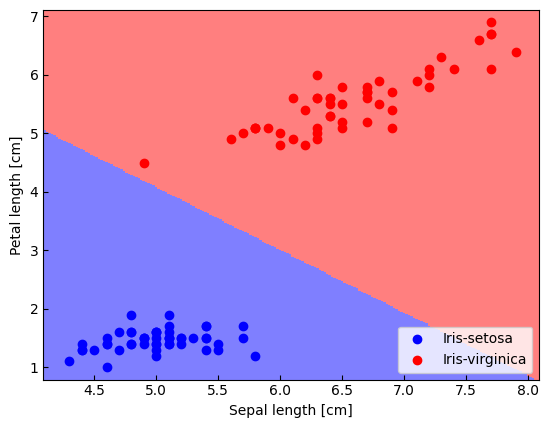

In [13]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red'], labels=None):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    y_model = model.predict(np.stack([x1.ravel(), x2.ravel()]).T)
    y_model = y_model.reshape(x1.shape)

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], color=colors[label], label=labels[label] if labels else None)
    ax.legend(loc='lower right')
    return ax

ax = plt.figure().gca()
plot_decision_boundary(ax, X, y_mapped, lr_model, labels=labels)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')